In [80]:
import numpy as np 
import pandas as pd 

In [81]:
!pip install snntorch

In [82]:
# imports
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils

import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
import random
import statistics
import tqdm
import scipy
from scipy.interpolate import interp1d 

In [83]:
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

/tmp/ipykernel_1126345/1028168213.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Id = 1e-9 * np.exp(np.divide(lin_vec,(2 * Vt)) - 1)


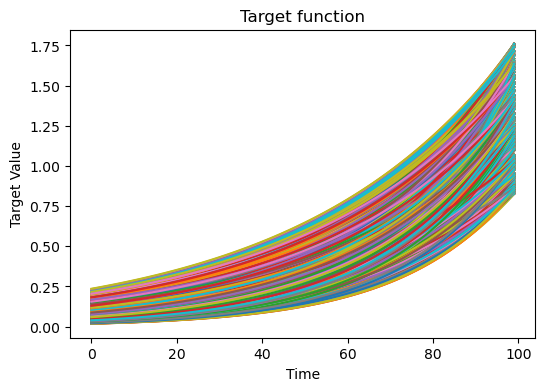

In [ ]:
class RegressionDataset(torch.utils.data.Dataset):
    """More complex sequence dataset for learning"""
    
    def __init__(self, timesteps, num_samples):
        self.num_samples = num_samples
        feature_lst, label_lst = [], []

        for i in range(num_samples):
            Vt =  (25 + 1 * float(torch.rand(1))) * 1e-3

            for _ in range(10):
                start = 0.8 + 0.1 * float(torch.rand(1))
                
                lin_vec = torch.linspace(start=start, end=1.0, steps=timesteps).view(-1, 1)
                Vt_tensor = torch.full_like(lin_vec,fill_value=Vt)
                Id = 1e-9 * np.exp(np.divide(lin_vec,(2 * Vt)) - 1)
                feature_lst.append(torch.cat([Vt_tensor,lin_vec],dim=1))
                label_lst.append(10 * Id)

        self.features = torch.stack(feature_lst, dim=1)
        self.labels = torch.stack(label_lst, dim=1)

    def __len__(self):
        return self.num_samples*10

    def __getitem__(self, idx):
        return self.features[:, idx, :], self.labels[:, idx, :]


# Test the dataset
num_steps = 100
num_samples = 200

dataset = RegressionDataset(timesteps=num_steps, num_samples=num_samples)

# Plot samples
plt.figure(figsize=(6, 4))
for i in range(num_samples*10):
    plt.plot(dataset.labels[:, i, 0], label=f"Sample {i+1}")
plt.title(f"Target function")
plt.xlabel("Time")
plt.ylabel("Target Value")
#plt.legend()
plt.show()

In [ ]:
batch_size = 64 # Increased from 16 to stabilize regression gradients
num_workers = 8 
dataloader = torch.utils.data.DataLoader(
    dataset=dataset, batch_size=batch_size, shuffle=True, 
    num_workers=num_workers, pin_memory=True
)

In [ ]:
# UPDATE ARCHITECTURE CELL
class Net(torch.nn.Module):
    def __init__(self, timesteps, hidden):
        super().__init__()
        self.timesteps = timesteps 
        self.hidden = hidden 
        spike_grad = surrogate.fast_sigmoid(slope=15) # Softened slope

        beta_in, thr_in = torch.rand(self.hidden), torch.rand(self.hidden)
        self.fc_in = torch.nn.Linear(in_features=2, out_features=self.hidden)
        self.lif_in = snn.Leaky(beta=beta_in, threshold=thr_in, learn_beta=True, learn_threshold=True, spike_grad=spike_grad)
        
        self.dropout = torch.nn.Dropout(0.2) # Added mild dropout

        beta_hidden, thr_hidden = torch.rand(self.hidden), torch.rand(self.hidden)
        self.fc_hidden = torch.nn.Linear(in_features=self.hidden, out_features=self.hidden)
        self.lif_hidden = snn.Leaky(beta=beta_hidden, threshold=thr_hidden, learn_beta=True, learn_threshold=True, spike_grad=spike_grad)

        beta_out = torch.rand(1)
        self.fc_out = torch.nn.Linear(in_features=self.hidden, out_features=1)
        self.lif_out = snn.Leaky(beta=beta_out, threshold=1.0, learn_beta=True, spike_grad=spike_grad, reset_mechanism="none")

    def forward(self, x):
        # ... same forward pass but insert: spk_in = self.dropout(spk_in) after first LIF layer


# UPDATE TRAINING LOOP CELL
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iter, eta_min=1e-6)

with tqdm.trange(num_iter) as pbar:
    for epoch in pbar:
        # ... inner loop ...
        for feature, label in train_batch:
            # ...
            optimizer.zero_grad()
            loss_val.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
            optimizer.step()
        
        scheduler.step() # Step at the end of epoch

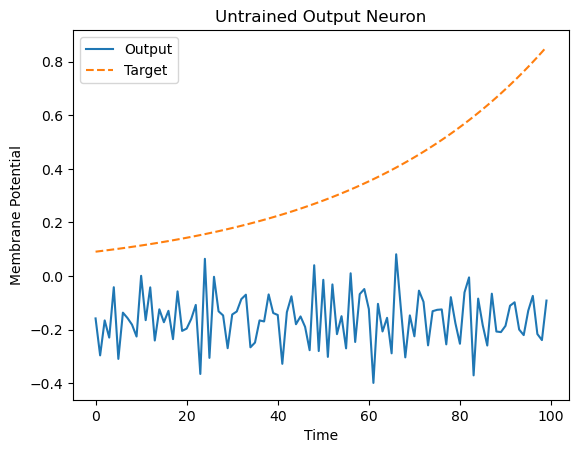

In [ ]:
hidden = 256 # Increased hidden capacity from 128 to 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net(timesteps=num_steps, hidden=hidden).to(device)

train_batch = iter(dataloader)

# run a single forward-pass
with torch.no_grad():
    for feature, label in train_batch:
        feature = torch.swapaxes(input=feature, axis0=0, axis1=1)
        label = torch.swapaxes(input=label, axis0=0, axis1=1)
        feature = feature.to(device)
        label = label.to(device)
        mem = model(feature)

# plot
plt.plot(mem[:, 0, 0].cpu(), label="Output")
plt.plot(label[:, -1, 0].cpu(), '--', label="Target")
plt.title("Untrained Output Neuron")
plt.xlabel("Time")
plt.ylabel("Membrane Potential")
plt.legend(loc='best')
plt.show()

In [ ]:
num_iter = 500  

# Switch to AdamW
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
# Add Cosine Annealing Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iter, eta_min=1e-6)
loss_function = torch.nn.MSELoss()

loss_hist = []
beta_in_hist, beta_hidden_hist, beta_out_hist = [], [], []
thr_in_hist, thr_hidden_hist = [], []

with tqdm.trange(num_iter) as pbar:
    for epoch in pbar:
        train_batch = iter(dataloader)
        minibatch_counter = 0
        loss_epoch = []

        for feature, label in train_batch:
            if feature is None or label is None:
                continue

            feature = torch.swapaxes(input=feature, axis0=0, axis1=1).to(device)
            label = torch.swapaxes(input=label, axis0=0, axis1=1).to(device)

            mem = model(feature)
            loss_val = loss_function(mem, label)
            
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())
            loss_epoch.append(loss_val.item())
            minibatch_counter += 1

        avg_batch_loss = sum(loss_epoch) / minibatch_counter if minibatch_counter > 0 else 0

        # Step the scheduler at the end of each epoch
        scheduler.step()

        # Track parameters
        beta_in_hist.append(model.lif_in.beta.detach().cpu().numpy().mean())
        beta_hidden_hist.append(model.lif_hidden.beta.detach().cpu().numpy().mean())
        beta_out_hist.append(model.lif_out.beta.detach().cpu().numpy().mean())

        thr_in_hist.append(model.lif_in.threshold.detach().cpu().numpy().mean())
        thr_hidden_hist.append(model.lif_hidden.threshold.detach().cpu().numpy().mean())

        pbar.set_postfix(loss="%.3e" % avg_batch_loss, lr="%.2e" % scheduler.get_last_lr()[0])

100%|██████████| 500/500 [1:38:26<00:00, 11.81s/it, loss=4.908e-03]


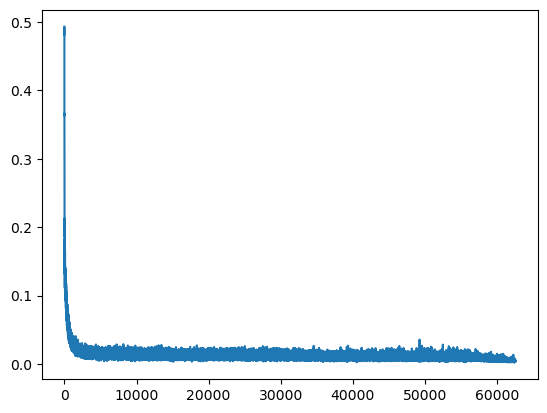

In [89]:
plt.plot(loss_hist)
plt.show()

Mean L1-loss:       1.28e-02
Mean rel. err.:     1.77e-01


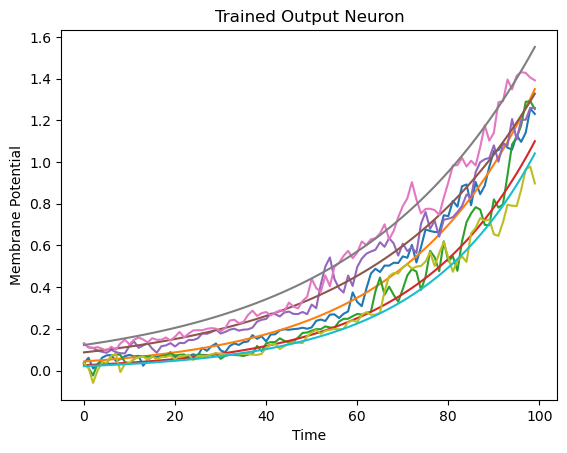

In [90]:
loss_function = torch.nn.L1Loss() # Use L1 loss instead

 # pause gradient calculation during evaluation
with torch.no_grad():
    model.eval()

    test_batch = iter(dataloader)
    minibatch_counter = 0
    rel_err_lst = []
    rmse_list = []
    loss_hist_test = []
    j = 0
    # loop over data samples
    for feature, label in test_batch:

        # prepare data
        feature = torch.swapaxes(input=feature, axis0=0, axis1=1)
        label = torch.swapaxes(input=label, axis0=0, axis1=1)
        feature = feature.to(device)
        label = label.to(device)

        # forward-pass
        mem = model(feature)

        # calculate relative error
        rel_err = torch.linalg.norm(
            (mem - label), dim=-1
        ) / torch.linalg.norm(label, dim=-1)
        rel_err = torch.mean(rel_err[1:, :])

        # calculate loss
        loss_val = loss_function(mem, label)

        rmse_loss = torch.sqrt(torch.mean((mem - label) ** 2))

        # store loss
        loss_hist_test.append(loss_val.item())
        rel_err_lst.append(rel_err.item())
        rmse_list.append(rmse_loss.item())
        minibatch_counter += 1

        mem = mem.cpu()
        label = label.cpu()
        
        if(j == 5):
            break 
        
        plt.title("Trained Output Neuron")
        plt.xlabel("Time")
        plt.ylabel("Membrane Potential")
        for i in range(1):
            plt.plot(mem[:, i, :].cpu(), label="Output")
            plt.plot(label[:, i, :].cpu(), label="Target")

        j += 1

    mean_L1 = statistics.mean(loss_hist)
    mean_rel = statistics.mean(rel_err_lst)

print(f"{'Mean L1-loss:':<{20}}{mean_L1:1.2e}")
print(f"{'Mean rel. err.:':<{20}}{mean_rel:1.2e}")

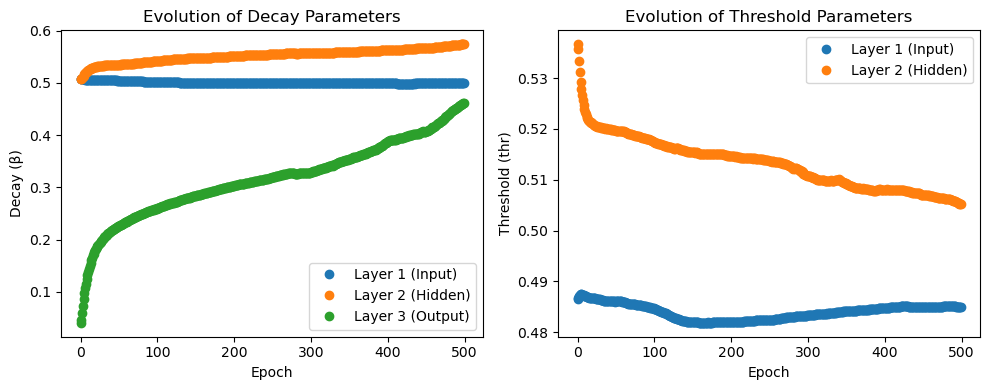

In [91]:
plt.figure(figsize=(10, 4))

# Plot β (decay)
plt.subplot(1, 2, 1)
plt.plot(beta_in_hist,'o', label="Layer 1 (Input)")
plt.plot(beta_hidden_hist,'o', label="Layer 2 (Hidden)")
plt.plot(beta_out_hist, 'o', label="Layer 3 (Output)")
plt.xlabel("Epoch")
plt.ylabel("Decay (β)")
plt.title("Evolution of Decay Parameters")
plt.legend()

# Plot Threshold (thr)
plt.subplot(1, 2, 2)
plt.plot(thr_in_hist,'o', label="Layer 1 (Input)")
plt.plot(thr_hidden_hist,'o', label="Layer 2 (Hidden)")
plt.xlabel("Epoch")
plt.ylabel("Threshold (thr)")
plt.title("Evolution of Threshold Parameters")
plt.legend()

plt.tight_layout()
plt.show()